# 1D-CNN v7 — Enhanced Calibration Pipeline

Same base model as v6. Three calibration improvements:
1. SVM RBF as calibration classifier (non-linear, better than LogReg)
2. More calibration data for S1 (all positions, not just p0)
3. Ensemble: weighted vote of base model + calibrated classifier

In [27]:
import sys, math, copy
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import mode

from config import RANDOM_SEED, N_CLASSES, MODELS_DIR, get_device, SUBJECTS_INTERDAY_LONG
from src.experiment_runner import (
    get_splits, load_and_norm, META,
    TEST_SUBJECTS, TRAIN_SUBJECTS,
)
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
DEVICE = get_device()
splits = get_splits()
print(f'Device: {DEVICE}')

Device: mps


## Model (same as v6)

In [28]:
class ECA1d(nn.Module):
    def __init__(self,ch):
        super().__init__()
        k = max(int(abs(math.log2(ch)/2+0.5)),3); k = k if k%2 else k+1
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1,1,k,padding=k//2,bias=False)
    def forward(self,x):
        b,c,t = x.size()
        return x * torch.sigmoid(self.conv(self.gap(x).view(b,1,c))).view(b,c,1).expand_as(x)

class SepConv1d(nn.Module):
    def __init__(self,ic,oc,k=5,p=2):
        super().__init__()
        self.dw = nn.Conv1d(ic,ic,k,padding=p,groups=ic)
        self.pw = nn.Conv1d(ic,oc,1)
    def forward(self,x): return self.pw(self.dw(x))

class TemporalSCNN(nn.Module):
    def __init__(self,in_ch=8,n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch,64,5,padding=2), nn.BatchNorm1d(64), nn.ReLU(), ECA1d(64), nn.MaxPool1d(2),
            SepConv1d(64,128,5,2), nn.BatchNorm1d(128), nn.ReLU(), ECA1d(128), nn.MaxPool1d(2),
            SepConv1d(128,256,3,1), nn.BatchNorm1d(256), nn.ReLU(), ECA1d(256), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(256,64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64,n_classes),
        )
    def forward(self,x): return self.classifier(self.features(x))
    def extract_feat(self,x):
        with torch.no_grad(): return nn.Flatten()(self.features(x))

print(f'Params: {sum(p.numel() for p in TemporalSCNN().parameters()):,}')

Params: 62,676


## Training (same as v6)

In [29]:
train_combined = pd.concat([splits['train_df'], splits['s5_train']])
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)
print(f'Train: {X_train.shape}')

model = TemporalSCNN().to(DEVICE)
model.load_state_dict(torch.load(MODELS_DIR / '1dcnn_v6.pt', map_location=DEVICE))
model.eval()
print('Loaded 1dcnn_v6.pt')

Loading windows: 100%|██████████| 9021/9021 [00:02<00:00, 3229.69it/s]


Train: (1030712, 8, 50)
Loaded 1dcnn_v6.pt


## Prediction + Feature extraction

In [30]:
@torch.no_grad()
def base_predict(X):
    model.eval()
    Xt = torch.from_numpy(X).float()
    loader = DataLoader(TensorDataset(Xt), batch_size=512, shuffle=False)
    return np.concatenate([model(xb[0].to(DEVICE)).argmax(1).cpu().numpy() for xb in loader])

@torch.no_grad()
def base_proba(X):
    model.eval()
    Xt = torch.from_numpy(X).float()
    loader = DataLoader(TensorDataset(Xt), batch_size=512, shuffle=False)
    probs = []
    for (xb,) in loader:
        logits = model(xb.to(DEVICE))
        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(probs)

@torch.no_grad()
def extract_features(X):
    model.eval()
    Xt = torch.from_numpy(X).float()
    loader = DataLoader(TensorDataset(Xt), batch_size=512, shuffle=False)
    return np.concatenate([model.extract_feat(xb[0].to(DEVICE)).cpu().numpy() for xb in loader])

## Enhanced calibration: SVM RBF + ensemble

In [31]:
def calibrate_svm(X_cal, y_cal):
    """Train SVM RBF on deep features from calibration data."""
    F_cal = extract_features(X_cal)
    sc = StandardScaler().fit(F_cal)
    F_cal_s = sc.transform(F_cal)
    svm = SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=RANDOM_SEED)
    svm.fit(F_cal_s, y_cal)
    return svm, sc


def ensemble_predict(X, svm, sc, base_weight=0.4, cal_weight=0.7):
    """Weighted ensemble: base model softmax + SVM calibrated probability."""
    # Base model probabilities
    p_base = base_proba(X)  # (N, 7)

    # SVM calibrated probabilities
    F = extract_features(X)
    F_s = sc.transform(F)
    p_cal = svm.predict_proba(F_s)  # (N, 7)

    # Weighted average
    p_combined = base_weight * p_base + cal_weight * p_cal
    return p_combined.argmax(axis=1)


def full_calibration(X_cal, y_cal, X_test):
    """Full pipeline: SVM calibration + ensemble."""
    svm, sc = calibrate_svm(X_cal, y_cal)
    return ensemble_predict(X_test, svm, sc)

## Option B — Zero-shot

In [32]:
print('Option B — Zero-shot:')
zero_results = {}
for sname, test_df in [('S1', splits['s1_test']), ('S2', splits['s2_test']),
                        ('S3', splits['s3_test']), ('S4', splits['s4_test']),
                        ('S5', splits['s5_test'])]:
    X_t, y_t, _ = load_and_norm(test_df, stats=norm_stats)
    acc = accuracy_score(y_t, base_predict(X_t))
    zero_results[sname] = acc
    print(f'  {sname}: {acc:.4f}')

Option B — Zero-shot:
  S1: 0.5862
  S2: 0.5352
  S3: 0.5398
  S4: 0.6556
  S5: 0.8029


---
## Option A — Enhanced Calibration

### S1: per-subject, rep 0 from ALL positions (not just p0)

In [33]:
# S1: use rep 0 from ALL positions as calibration (much more data)
subset_s1_full = META[(META['session'] == 0) & (META['subject'].isin(TEST_SUBJECTS))]

s1_base, s1_cal = [], []
for subj in TEST_SUBJECTS:
    sdf = subset_s1_full[subset_s1_full['subject'] == subj]
    cal_df = sdf[sdf['repetition'].isin([0, 1])]
    test_df = sdf[sdf['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    s1_base.append(accuracy_score(y_test, base_predict(X_test)))
    y_pred = full_calibration(X_cal, y_cal, X_test)
    s1_cal.append(accuracy_score(y_test, y_pred))
    print(f'  {subj}: base={s1_base[-1]:.4f}  cal={s1_cal[-1]:.4f}')

cal_s1 = np.mean(s1_cal)
print(f'\nS1 avg: base={np.mean(s1_base):.4f}  cal={cal_s1:.4f}')

  h7: base=0.5737  cal=0.8950
  h22: base=0.6138  cal=0.8020
  h3: base=0.5017  cal=0.8157
  h24: base=0.5288  cal=0.8747
  h16: base=0.5420  cal=0.8718
  h17: base=0.4174  cal=0.8408

S1 avg: base=0.5296  cal=0.8500


### S2: per-position calibration

In [34]:
subset_s2 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS)) & (META['position']>0)]

s2_accs = []
for pos in sorted(subset_s2['position'].unique()):
    pos_df = subset_s2[subset_s2['position'] == pos]
    cal_df = pos_df[pos_df['repetition'].isin([0, 1])]
    test_df = pos_df[pos_df['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred = full_calibration(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s2_accs.append(acc)
    print(f'  Pos {pos:2d}: {acc:.4f}')

cal_s2 = np.mean(s2_accs)
print(f'\nS2 avg: {cal_s2:.4f}')

  Pos  1: 0.8327
  Pos  2: 0.8979
  Pos  3: 0.8287
  Pos  4: 0.8502
  Pos  5: 0.8798
  Pos  6: 0.8328
  Pos  7: 0.8797
  Pos  8: 0.8530
  Pos  9: 0.8656
  Pos 10: 0.8084

S2 avg: 0.8529


### S3: per-subject, rep 0 all positions

In [35]:
subset_s3 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS))]

s3_accs = []
all_yt, all_yp = [], []
for subj in TEST_SUBJECTS:
    sdf = subset_s3[subset_s3['subject'] == subj]
    cal_df = sdf[sdf['repetition'].isin([0, 1])]
    test_df = sdf[sdf['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred = full_calibration(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s3_accs.append(acc)
    all_yt.extend(y_test); all_yp.extend(y_pred)
    print(f'  {subj}: {acc:.4f} (cal={len(cal_df)} trials)')

cal_s3 = np.mean(s3_accs)
print(f'\nS3 avg: {cal_s3:.4f}')
print_report(np.array(all_yt), np.array(all_yp), title='v7 — S3')

  h7: 0.8950 (cal=154 trials)
  h22: 0.8020 (cal=154 trials)
  h3: 0.8157 (cal=154 trials)
  h24: 0.8747 (cal=153 trials)
  h16: 0.8718 (cal=154 trials)
  h17: 0.8408 (cal=154 trials)

S3 avg: 0.8500

  v7 — S3
  Accuracy:  0.8489
  F1-macro:  0.8488
                    precision    recall  f1-score   support

              fist       0.88      0.85      0.87      7959
         open_hand       0.83      0.85      0.84      8060
  pinch_forefinger       0.84      0.79      0.81      8091
pinch_middlefinger       0.85      0.84      0.84      8099
               two       0.84      0.86      0.85      7970
          eversion       0.85      0.91      0.88      7903
             varus       0.85      0.84      0.85      8064

          accuracy                           0.85     56146
         macro avg       0.85      0.85      0.85     56146
      weighted avg       0.85      0.85      0.85     56146



{'accuracy': 0.8489295764613686, 'f1_macro': 0.8488184228034247}

### S4: per-session calibration

In [36]:
interday_subjects = [s for s in SUBJECTS_INTERDAY_LONG if s in TRAIN_SUBJECTS]
subset_s4 = META[(META['subject'].isin(interday_subjects)) & (META['position']==0) & (META['session']>0)]

s4_accs = []
for sess in sorted(subset_s4['session'].unique()):
    sess_df = subset_s4[subset_s4['session'] == sess]
    cal_df = sess_df[sess_df['repetition'].isin([0, 1])]
    test_df = sess_df[sess_df['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred = full_calibration(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s4_accs.append(acc)
    print(f'  Session {sess}: {acc:.4f}')

cal_s4 = np.mean(s4_accs)
print(f'\nS4 avg: {cal_s4:.4f}')

  Session 1: 0.8313
  Session 2: 0.8705
  Session 3: 0.8843
  Session 4: 0.8961
  Session 5: 0.8769
  Session 6: 0.8504
  Session 7: 0.8595
  Session 8: 0.9195
  Session 9: 0.9010

S4 avg: 0.8766


### S5: per-position calibration

In [37]:
from config import SUBJECTS_FATIGUE
subset_s5 = META[(META['subject'].isin(SUBJECTS_FATIGUE)) & (META['position']>=2)]

s5_accs = []
for pos in sorted(subset_s5['position'].unique()):
    pos_df = subset_s5[subset_s5['position'] == pos]
    cal_df = pos_df[pos_df['repetition'].isin([0, 1])]
    test_df = pos_df[pos_df['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred = full_calibration(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s5_accs.append(acc)
    print(f'  Pos {pos:2d}: {acc:.4f}')

cal_s5 = np.mean(s5_accs)
print(f'\nS5 avg: {cal_s5:.4f}')

  Pos  2: 0.8577
  Pos  3: 0.8510
  Pos  4: 0.8900
  Pos  5: 0.8888
  Pos  6: 0.8960
  Pos  7: 0.8883
  Pos  8: 0.8818
  Pos  9: 0.8917
  Pos 10: 0.9052

S5 avg: 0.8834


## Latency

In [38]:
model.eval()
s = torch.randn(1,8,50).to(DEVICE)
for _ in range(10): _ = model(s)
if DEVICE.type=='mps': torch.mps.synchronize()
def pred_single(x):
    xt = torch.from_numpy(x).float().to(DEVICE)
    with torch.no_grad(): out = model(xt)
    if DEVICE.type=='mps': torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()
latency = measure_latency(pred_single, X_train[:1], n_runs=500)
print_latency(latency, '1D-CNN v7')


Latency — 1D-CNN v7
  Mean:   1.98 ms
  Median: 2.01 ms
  P95:    2.26 ms
  <300ms: ✓


## Final Results


  1D-CNN v7 — FINAL RESULTS
Scenario        Zero-shot    v6 LogReg   v7 SVM+Ens   ≥85%
-----------------------------------------------------------------
S1                58.62%       70.46%       85.00%     ✓ (Δ=+14.54%)
S2                53.52%       76.57%       85.29%     ✓ (Δ=+8.72%)
S3                53.98%       76.75%       85.00%     ✓ (Δ=+8.25%)
S4                65.56%       81.37%       87.66%     ✓ (Δ=+6.29%)
S5                80.29%       86.23%       88.34%     ✓ (Δ=+2.11%)
-----------------------------------------------------------------
Average           62.39%       78.28%       86.26%


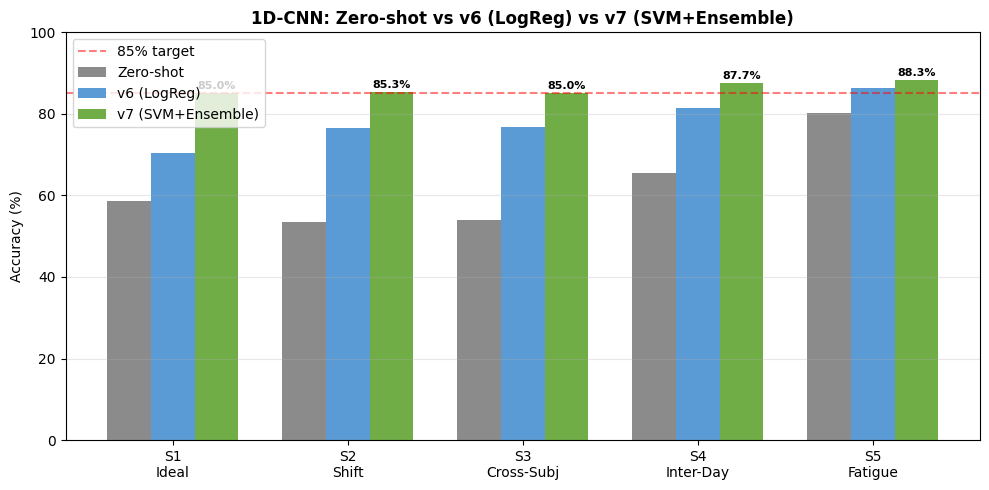

In [39]:
import matplotlib.pyplot as plt

cal_results = {'S1': cal_s1, 'S2': cal_s2, 'S3': cal_s3, 'S4': cal_s4, 'S5': cal_s5}

print('\n' + '=' * 65)
print('  1D-CNN v7 — FINAL RESULTS')
print('=' * 65)
print(f'{"Scenario":<12} {"Zero-shot":>12} {"v6 LogReg":>12} {"v7 SVM+Ens":>12} {"≥85%":>6}')
print('-' * 65)

v6_cal = {'S1': 70.46, 'S2': 76.57, 'S3': 76.75, 'S4': 81.37, 'S5': 86.23}

for s in ['S1','S2','S3','S4','S5']:
    zs = zero_results[s] * 100
    v6 = v6_cal[s]
    v7 = cal_results[s] * 100
    delta = v7 - v6
    check = '✓' if v7 >= 85 else ''
    print(f'{s:<12} {zs:>10.2f}%  {v6:>10.2f}%  {v7:>10.2f}%  {check:>4} (Δ={delta:+.2f}%)')

print('-' * 65)
avg_zs = np.mean([zero_results[s]*100 for s in ['S1','S2','S3','S4','S5']])
avg_v6 = np.mean(list(v6_cal.values()))
avg_v7 = np.mean([cal_results[s]*100 for s in ['S1','S2','S3','S4','S5']])
print(f'{"Average":<12} {avg_zs:>10.2f}%  {avg_v6:>10.2f}%  {avg_v7:>10.2f}%')
print('=' * 65)

# Bar chart comparison
scenarios = ['S1','S2','S3','S4','S5']
x = np.arange(5)
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, [zero_results[s]*100 for s in scenarios], w, label='Zero-shot', color='#8B8B8B')
ax.bar(x, [v6_cal[s] for s in scenarios], w, label='v6 (LogReg)', color='#5B9BD5')
ax.bar(x + w, [cal_results[s]*100 for s in scenarios], w, label='v7 (SVM+Ensemble)', color='#70AD47')
ax.axhline(y=85, color='red', ls='--', alpha=0.5, label='85% target')
ax.set_xticks(x)
ax.set_xticklabels(['S1\nIdeal', 'S2\nShift', 'S3\nCross-Subj', 'S4\nInter-Day', 'S5\nFatigue'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('1D-CNN: Zero-shot vs v6 (LogReg) vs v7 (SVM+Ensemble)', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, s in enumerate(scenarios):
    ax.text(i+w, cal_results[s]*100+1, f'{cal_results[s]*100:.1f}%', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(str(Path(PROJECT_ROOT) / 'results' / 'figures' / '1dcnn_v7_comparison.png'), dpi=150)
plt.show()